# Diseño de Experimentos (Parte II)

**Curso:** Análisis de Datos  
**Tema:** Tamaño de Muestra, Validación de Supuestos y Diseño de Bloques

***

## Contenido

1. **Elección del Tamaño de la Muestra**
   - Cálculo del tamaño de muestra: potencia estadística y tamaño del efecto
   - Consideraciones prácticas y teóricas

2. **Validación de los Supuestos del Modelo**
   - Verificación de independencia
   - Verificación de varianza constante (homocedasticidad)
   - Verificación de normalidad de residuos

3. **Diseño de Bloques Completamente Aleatorizados (DBCA)**
   - Concepto y motivación del bloqueo
   - Modelo estadístico y tabla ANOVA
   - Aplicación e interpretación de resultados

***
> **Objetivo:** Al finalizar este taller el estudiante podrá determinar el tamaño de muestra necesario para un experimento, validar formalmente los supuestos del modelo ANOVA, y analizar experimentos con diseño de bloques en Python.

## Librerías necesarias

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.power import FTestAnovaPower
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style='whitegrid', palette='Set2')
print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


***
# 1. Elección del Tamaño de la Muestra

## 1.1 ¿Por qué es importante el tamaño de muestra?

Determinar el **tamaño de muestra** antes de ejecutar el experimento es una decisión crítica que afecta:

- **Potencia estadística ($1-\beta$):** probabilidad de detectar un efecto real cuando existe.
- **Error de Tipo I ($\alpha$):** probabilidad de rechazar $H_0$ siendo verdadera (nivel de significancia).
- **Error de Tipo II ($\beta$):** probabilidad de no detectar un efecto real.
- **Costo del experimento:** más réplicas = mayor costo y tiempo.

### Relación entre los errores y la potencia

| Decisión / Realidad | $H_0$ verdadera | $H_0$ falsa |
|---------------------|-----------------|-------------|
| **No rechazar $H_0$** | Decisión correcta ($1-\alpha$) | Error Tipo II ($\beta$) |
| **Rechazar $H_0$** | Error Tipo I ($\alpha$) | Decisión correcta ($1-\beta$ = potencia) |

> **Convenio:** $\alpha = 0.05$ y potencia $\geq 0.80$ son los estándares más utilizados en investigación.

***

## 1.2 Requerimientos calcular el tamaño de muestra

Para calcular $n$ (réplicas por tratamiento) en un ANOVA de una vía se necesitan:

1. **Nivel de significancia** $\alpha$ (típicamente 0.05).
2. **Potencia deseada** $1 - \beta$ (típicamente 0.80 o 0.90).
3. **Número de tratamientos** $k$.
4. **Tamaño del efecto** $f$ (cuán grandes son las diferencias entre medias):

$$f = \frac{\sigma_{\tau}}{\sigma} = \frac{\sqrt{\frac{1}{k}\sum_{i=1}^{k}(\mu_i - \mu)^2}}{\sigma}$$

donde $\sigma_\tau$ es la desviación estándar de las medias de los tratamientos y $\sigma$ es la desviación estándar del error.

### Escala de Cohen para el tamaño del efecto $f$

| $f$ | Interpretación |
|-----|---------------|
| 0.10 | Efecto pequeño |
| 0.25 | Efecto mediano |
| 0.40 | Efecto grande |

In [30]:
# ------------------------------------------------------------------
# Cálculo del tamaño de muestra usando análisis de potencia (ANOVA)
# statsmodels.stats.power.FTestAnovaPower
# ------------------------------------------------------------------
analisis_potencia = FTestAnovaPower()

# Parámetros del experimento de fertilizantes (mismo contexto del Taller I)
k       = 4          # número de tratamientos
alpha   = 0.05       # nivel de significancia
potencia_objetivo = 0.80   # potencia deseada

# Tamaño del efecto calculado desde las medias reales y sigma
medias_trat = np.array([380, 420, 460, 400])
sigma_error = 30.0
mu_global   = medias_trat.mean()
sigma_tau   = np.sqrt(np.mean((medias_trat - mu_global) ** 2))
f_cohen     = sigma_tau / sigma_error

print(f"Medias por tratamiento : {medias_trat}")
print(f"Media global           : {mu_global:.1f} kg/ha")
print(f"σ_τ (desv. estándar de las medias) : {sigma_tau:.2f}")
print(f"σ   (error del proceso)            : {sigma_error:.2f}")
print(f"Tamaño del efecto Cohen f          : {f_cohen:.3f}")
print()

# n mínimo para la potencia objetivo
n_necesario = analisis_potencia.solve_power(
    effect_size=f_cohen,
    alpha=alpha,
    power=potencia_objetivo,
    k_groups=k
)
n_necesario = int(np.ceil(n_necesario))

print(f"Réplicas mínimas por tratamiento para alcanzar potencia {potencia_objetivo}: n = {n_necesario}")
print(f"Total de observaciones requeridas: N = {n_necesario * k}")

Medias por tratamiento : [380 420 460 400]
Media global           : 415.0 kg/ha
σ_τ (desv. estándar de las medias) : 29.58
σ   (error del proceso)            : 30.00
Tamaño del efecto Cohen f          : 0.986

Réplicas mínimas por tratamiento para alcanzar potencia 0.8: n = 16
Total de observaciones requeridas: N = 64


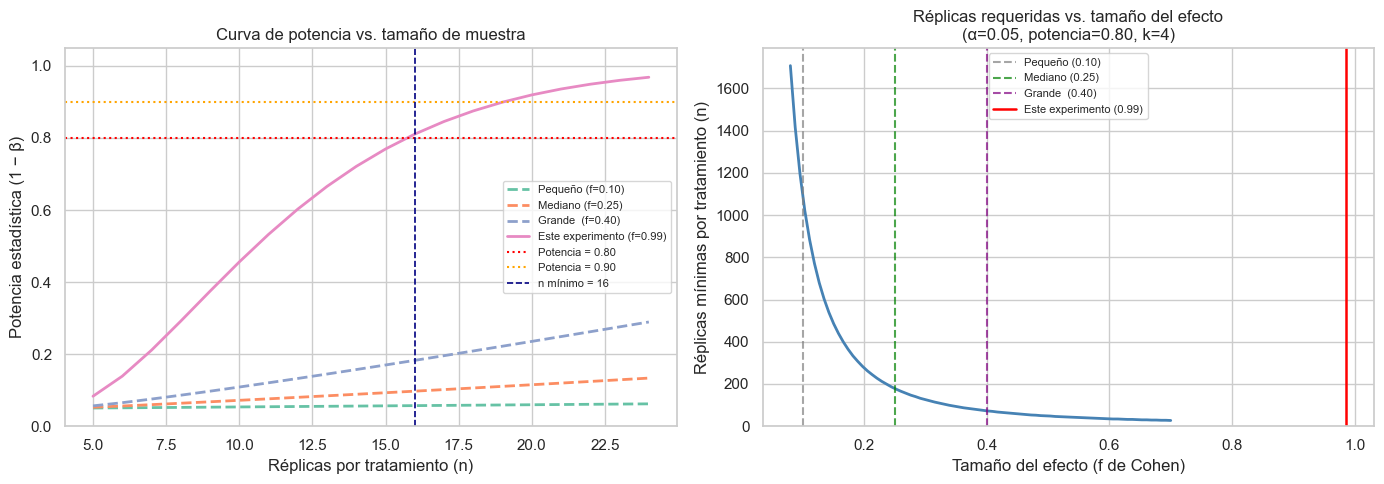

In [31]:
# ------------------------------------------------------------------
# Curva Potencia vs. n  y  Potencia vs. tamaño del efecto
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Potencia vs. número de réplicas (n) ---
n_vals = np.arange(2, 25)
for f_val, etiqueta in [(0.10, 'Pequeño (f=0.10)'),
                         (0.25, 'Mediano (f=0.25)'),
                         (0.40, 'Grande  (f=0.40)'),
                         (f_cohen, f'Este experimento (f={f_cohen:.2f})')]:
    potencias = [analisis_potencia.power(effect_size=f_val, nobs=n, alpha=alpha, k_groups=k)
                 for n in n_vals]
    ls = '--' if 'experimento' not in etiqueta else '-'
    axes[0].plot(n_vals, potencias, label=etiqueta, linewidth=2, linestyle=ls)

axes[0].axhline(0.80, color='red', linestyle=':', linewidth=1.5, label='Potencia = 0.80')
axes[0].axhline(0.90, color='orange', linestyle=':', linewidth=1.5, label='Potencia = 0.90')
axes[0].axvline(n_necesario, color='navy', linestyle='--', linewidth=1.2,
                label=f'n mínimo = {n_necesario}')
axes[0].set_xlabel('Réplicas por tratamiento (n)')
axes[0].set_ylabel('Potencia estadística (1 − β)')
axes[0].set_title('Curva de potencia vs. tamaño de muestra')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.05)

# --- Panel 2: n requerido vs. tamaño del efecto para potencia = 0.80 ---
f_vals = np.linspace(0.08, 0.70, 80)
n_req  = [int(np.ceil(analisis_potencia.solve_power(
              effect_size=f, alpha=alpha, power=0.80, k_groups=k)))
          for f in f_vals]

axes[1].plot(f_vals, n_req, color='steelblue', linewidth=2)
axes[1].axvline(0.10, color='gray',   linestyle='--', alpha=0.7, label='Pequeño (0.10)')
axes[1].axvline(0.25, color='green',  linestyle='--', alpha=0.7, label='Mediano (0.25)')
axes[1].axvline(0.40, color='purple', linestyle='--', alpha=0.7, label='Grande  (0.40)')
axes[1].axvline(f_cohen, color='red', linestyle='-',  linewidth=1.8,
                label=f'Este experimento ({f_cohen:.2f})')
axes[1].set_xlabel('Tamaño del efecto (f de Cohen)')
axes[1].set_ylabel('Réplicas mínimas por tratamiento (n)')
axes[1].set_title('Réplicas requeridas vs. tamaño del efecto\n(α=0.05, potencia=0.80, k=4)')
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, None)

plt.tight_layout()
plt.show()

## 1.3 Consideraciones Prácticas y Teóricas

### Consideraciones teóricas

- **Cuando $f$ es desconocido:** se puede estimar a partir de estudios piloto, literatura previa o experiencia de dominio. Usar el escenario más conservador (efecto mediano, $f=0.25$) si no hay información.
- **Diseños desbalanceados:** si los grupos no tienen igual $n$, la potencia se reduce. Siempre preferir balance.
- **Múltiples niveles de $\alpha$ y potencia:** generar una tabla de sensibilidad para distintas combinaciones.

### Consideraciones prácticas

| Factor | Recomendación |
|--------|---------------|
| **Costo por unidad experimental** | Considerar el balance costo-potencia; n mínimo viable |
| **Disponibilidad de material** | Puede imponer un límite superior real de $n$ |
| **Variabilidad desconocida** | Aumentar $n$ un 10–20% como margen de seguridad |
| **Pérdida de datos (dropout)** | Planear con $n' = n / (1 - p_{pérdida})$ |
| **Efecto mínimo detectable** | Definir cuál es la diferencia *prácticamente importante*, no solo estadísticamente significativa |

### Tabla de sensibilidad: n vs. potencia para múltiples niveles

In [32]:
# ------------------------------------------------------------------
# Tabla de sensibilidad: n mínimo para distintas combinaciones de
# α, potencia y tamaño del efecto
# ------------------------------------------------------------------
alphas    = [0.05, 0.01]
potencias = [0.70, 0.80, 0.90, 0.95]
efectos   = {'Pequeño\n(f=0.10)': 0.10,
             'Mediano\n(f=0.25)': 0.25,
             'Grande\n(f=0.40)': 0.40}

print("Réplicas mínimas por tratamiento (k=4 tratamientos)\n")
for a in alphas:
    print(f"  α = {a}")
    encabezado = f"  {'Potencia':>10} | " + " | ".join(f"{e:>14}" for e in efectos)
    print(encabezado)
    print("  " + "-" * (len(encabezado) - 2))
    for pot in potencias:
        fila = f"  {pot:>10.2f} | "
        for f_val in efectos.values():
            n_req = int(np.ceil(
                analisis_potencia.solve_power(
                    effect_size=f_val, alpha=a, power=pot, k_groups=k)
            ))
            fila += f"{n_req:>14d} | "
        print(fila)
    print()

print("Nota: para este experimento (f ≈ {:.2f}), se recomienda n = {} réplicas/trat.".format(
    f_cohen, n_necesario))

Réplicas mínimas por tratamiento (k=4 tratamientos)

  α = 0.05
    Potencia | Pequeño
(f=0.10) | Mediano
(f=0.25) | Grande
(f=0.40)
  ------------------------------------------------------------------
        0.70 |            884 |            145 |             59 | 
        0.80 |           1095 |            179 |             73 | 
        0.90 |           1422 |            231 |             93 | 
        0.95 |           1721 |            279 |            112 | 

  α = 0.01
    Potencia | Pequeño
(f=0.10) | Mediano
(f=0.25) | Grande
(f=0.40)
  ------------------------------------------------------------------
        0.70 |           1303 |            214 |             87 | 
        0.80 |           1552 |            254 |            103 | 
        0.90 |           1931 |            314 |            127 | 
        0.95 |           2274 |            369 |            148 | 

Nota: para este experimento (f ≈ 0.99), se recomienda n = 16 réplicas/trat.


***
# 2. Validación de los Supuestos del Modelo

El modelo lineal del ANOVA descansa en tres supuestos sobre los errores $\varepsilon_{ij}$:

$$\varepsilon_{ij} \overset{\text{iid}}{\sim} N(0, \sigma^2)$$

| Supuesto | Descripción técnica | Consecuencia de violarlo |
|----------|---------------------|--------------------------|
| **Independencia** | Las observaciones no están correlacionadas entre sí | Subestimación del error; $F$ inflado |
| **Homocedasticidad** | $\text{Var}(\varepsilon_{ij}) = \sigma^2$ constante en todos los tratamientos | Intervalos de confianza y pruebas $F$ incorrectas |
| **Normalidad** | Los errores siguen distribución normal | Afecta pruebas $F$ con muestras pequeñas |

> **Importante:** Los supuestos se verifican sobre los **residuos del modelo** $e_{ij} = y_{ij} - \hat{y}_{ij}$, no sobre los datos crudos.

***

## 2.1 Datos de trabajo

Utilizamos el experimento de fertilizantes del Taller I, pero con el tamaño de muestra calculado ($n = $ `n_necesario`).

In [33]:
# ------------------------------------------------------------------
# Generar datos del experimento con n = n_necesario
# ------------------------------------------------------------------
np.random.seed(7)

tratamientos_lab = ['Fertilizante A', 'Fertilizante B', 'Fertilizante C', 'Fertilizante D']
medias_dict = dict(zip(tratamientos_lab, medias_trat))

registros = []
for i, (trat, media) in enumerate(medias_dict.items()):
    for rep in range(1, n_necesario + 1):
        y = np.random.normal(loc=media, scale=sigma_error)
        registros.append({'Tratamiento': trat, 'Replica': rep,
                          'Orden': i * n_necesario + rep,
                          'Rendimiento': round(y, 2)})

df = pd.DataFrame(registros)

# Ajuste del modelo ANOVA
modelo = ols('Rendimiento ~ C(Tratamiento)', data=df).fit()
df['Residuos'] = modelo.resid
df['Ajustados'] = modelo.fittedvalues

print(f"Experimento con n = {n_necesario} réplicas por tratamiento, N = {len(df)} obs. totales")
print(df.groupby('Tratamiento')['Rendimiento']
        .agg(n='count', Media='mean', DE='std').round(2).to_string())

Experimento con n = 16 réplicas por tratamiento, N = 64 obs. totales
                 n   Media     DE
Tratamiento                      
Fertilizante A  16  377.17  25.82
Fertilizante B  16  419.34  34.83
Fertilizante C  16  455.21  40.34
Fertilizante D  16  402.43  29.55


## 2.2 Verificación de Independencia

### ¿Cómo verificarla?

La independencia se garantiza principalmente por el **diseño del experimento** (aleatorización). Sin embargo, se puede detectar dependencia estructural mediante:

- **Gráfico de residuos vs. orden de ejecución:** si hay un patrón sistemático (tendencia, ciclos), puede indicar autocorrelación.
- **Prueba de Durbin-Watson:** valor cercano a 2 indica independencia; < 1.5 o > 2.5 son señales de alerta.

$$DW = \frac{\sum_{t=2}^{N}(e_t - e_{t-1})^2}{\sum_{t=1}^{N}e_t^2}$$

| Valor DW | Interpretación |
|----------|---------------|
| ≈ 2 | Sin autocorrelación |
| < 1.5 | Posible autocorrelación positiva |
| > 2.5 | Posible autocorrelación negativa |

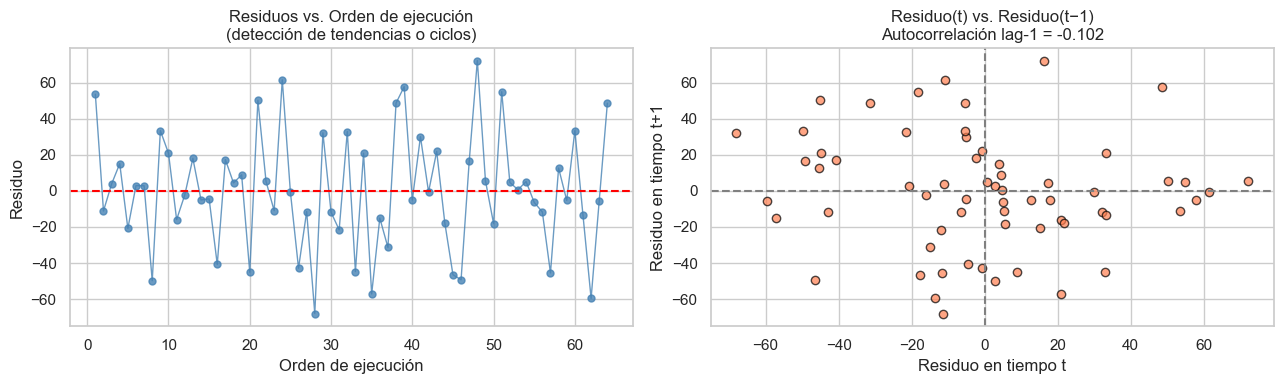

Estadístico Durbin-Watson: DW = 2.1142
→ Sin evidencia de autocorrelación. Supuesto de independencia satisfecho ✓


In [34]:
# ------------------------------------------------------------------
# Verificación de independencia: residuos vs. orden de ejecución
# + estadístico Durbin-Watson
# ------------------------------------------------------------------
from statsmodels.stats.stattools import durbin_watson

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Residuos en orden de ejecución
axes[0].plot(df['Orden'], df['Residuos'], 'o-', color='steelblue',
             markersize=5, linewidth=1, alpha=0.8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Orden de ejecución')
axes[0].set_ylabel('Residuo')
axes[0].set_title('Residuos vs. Orden de ejecución\n(detección de tendencias o ciclos)')

# Autocorrelación de los residuos (ACF manual para primer rezago)
rezagos = df['Residuos'].values
autocorr_1 = np.corrcoef(rezagos[:-1], rezagos[1:])[0, 1]
axes[1].scatter(rezagos[:-1], rezagos[1:], color='coral', edgecolors='black', alpha=0.7)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].axvline(0, color='gray', linestyle='--')
axes[1].set_title(f'Residuo(t) vs. Residuo(t−1)\nAutocorrelación lag-1 = {autocorr_1:.3f}')
axes[1].set_xlabel('Residuo en tiempo t')
axes[1].set_ylabel('Residuo en tiempo t+1')

plt.tight_layout()
plt.show()

# Estadístico Durbin-Watson
dw = durbin_watson(df['Residuos'])
print(f"Estadístico Durbin-Watson: DW = {dw:.4f}")
if 1.5 <= dw <= 2.5:
    print("→ Sin evidencia de autocorrelación. Supuesto de independencia satisfecho ✓")
elif dw < 1.5:
    print("→ Posible autocorrelación POSITIVA. Revisar el orden de ejecución ⚠")
else:
    print("→ Posible autocorrelación NEGATIVA. Revisar el orden de ejecución ⚠")

## 2.3 Verificación de Varianza Constante (Homocedasticidad)

### Métodos de verificación

**Gráficos:**
- **Residuos vs. valores ajustados:** los residuos deben dispersarse aleatoriamente en torno a cero sin formación de embudos o patrones.
- **Escala-Ubicación (Scale-Location):** la raíz cuadrada del residuo estandarizado frente al valor ajustado; la línea suavizada debe ser horizontal.

**Pruebas formales:**

| Prueba | Hipótesis nula | Característica |
|--------|---------------|----------------|
| **Levene** | $\sigma_1^2 = \cdots = \sigma_k^2$ | Robusta a no normalidad; usa medianas |
| **Bartlett** | $\sigma_1^2 = \cdots = \sigma_k^2$ | Potente pero sensible a no normalidad |
| **Fligner-Killeen** | $\sigma_1^2 = \cdots = \sigma_k^2$ | No paramétrica; muy robusta |

> Si $p < 0.05$ → evidencia de heterocedasticidad → considerar transformación de la respuesta (log, raíz cuadrada) o usar ANOVA de Welch.

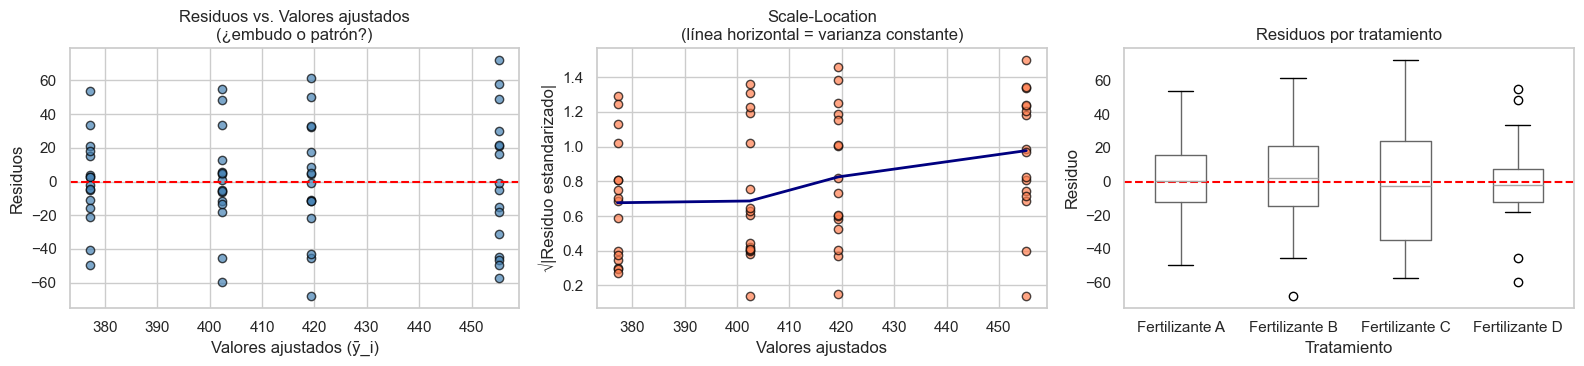

Pruebas de homogeneidad de varianzas:

          Prueba  Estadístico  p-valor Conclusión
Levene (mediana)       1.7024   0.1761       OK ✓
        Bartlett       3.2699   0.3519       OK ✓
 Fligner-Killeen       4.5589   0.2071       OK ✓


In [35]:
# ------------------------------------------------------------------
# Verificación de homocedasticidad: gráficos + pruebas formales
# ------------------------------------------------------------------
res_std = modelo.get_influence().resid_studentized_internal
sqrt_abs_res = np.sqrt(np.abs(res_std))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: Residuos vs. valores ajustados
axes[0].scatter(df['Ajustados'], df['Residuos'],
                color='steelblue', edgecolors='black', alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Valores ajustados (ȳ_i)')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs. Valores ajustados\n(¿embudo o patrón?)')

# Panel 2: Scale-Location
axes[1].scatter(df['Ajustados'], sqrt_abs_res,
                color='coral', edgecolors='black', alpha=0.7)
lowess_fit = sm.nonparametric.lowess(sqrt_abs_res, df['Ajustados'], frac=0.6)
axes[1].plot(lowess_fit[:, 0], lowess_fit[:, 1], color='navy', linewidth=2)
axes[1].set_xlabel('Valores ajustados')
axes[1].set_ylabel('√|Residuo estandarizado|')
axes[1].set_title('Scale-Location\n(línea horizontal = varianza constante)')

# Panel 3: Boxplot de residuos por tratamiento
df.boxplot(column='Residuos', by='Tratamiento', ax=axes[2], grid=False)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuos por tratamiento')
axes[2].set_xlabel('Tratamiento')
axes[2].set_ylabel('Residuo')
plt.suptitle('')  # quitar el título automático de boxplot

plt.tight_layout()
plt.show()

# Pruebas formales
grupos = [grp['Residuos'].values for _, grp in df.groupby('Tratamiento')]

stat_lev, p_lev   = stats.levene(*grupos, center='median')
stat_bart, p_bart = stats.bartlett(*grupos)
stat_fk, p_fk     = stats.fligner(*grupos)

print("Pruebas de homogeneidad de varianzas:\n")
resultados_var = pd.DataFrame({
    'Prueba':      ['Levene (mediana)', 'Bartlett', 'Fligner-Killeen'],
    'Estadístico': [round(stat_lev, 4), round(stat_bart, 4), round(stat_fk, 4)],
    'p-valor':     [round(p_lev, 4), round(p_bart, 4), round(p_fk, 4)],
    'Conclusión':  ['OK ✓' if p > 0.05 else '⚠ Posible heterocedasticidad'
                    for p in [p_lev, p_bart, p_fk]]
})
print(resultados_var.to_string(index=False))

## 2.4 Verificación de Normalidad de Residuos

### Métodos de verificación

**Gráfico Q-Q (quantile-quantile):** compara los cuantiles de los residuos con los de una distribución normal teórica. Si los puntos siguen la línea diagonal, el supuesto es razonable.

**Histograma de residuos:** debe aproximarse a una campana de Gauss centrada en cero.

**Pruebas formales:**

| Prueba | Hipótesis nula | Indicada para |
|--------|---------------|---------------|
| **Shapiro-Wilk** | Los datos provienen de una distribución normal | $n < 50$ (alta potencia con muestras pequeñas) |
| **Kolmogorov-Smirnov** (Lilliefors) | Idem | $n \geq 50$ |
| **Anderson-Darling** | Idem | Sensible en las colas |

> **Nota:** El ANOVA es **robusto** a desviaciones moderadas de la normalidad cuando $n$ es suficientemente grande (Teorema Central del Límite). El gráfico Q-Q es más informativo que la prueba formal en muestras grandes.

### Acciones correctivas si se viola normalidad

| Situación | Acción |
|-----------|--------|
| Asimetría positiva (cola derecha) | Transformación logarítmica: $y' = \log(y)$ |
| Datos de conteo (Poisson) | Transformación raíz cuadrada: $y' = \sqrt{y}$ |
| Datos proporciones | Transformación arcoseno: $y' = \arcsin(\sqrt{y})$ |
| Violación grave | Usar prueba no paramétrica: Kruskal-Wallis |

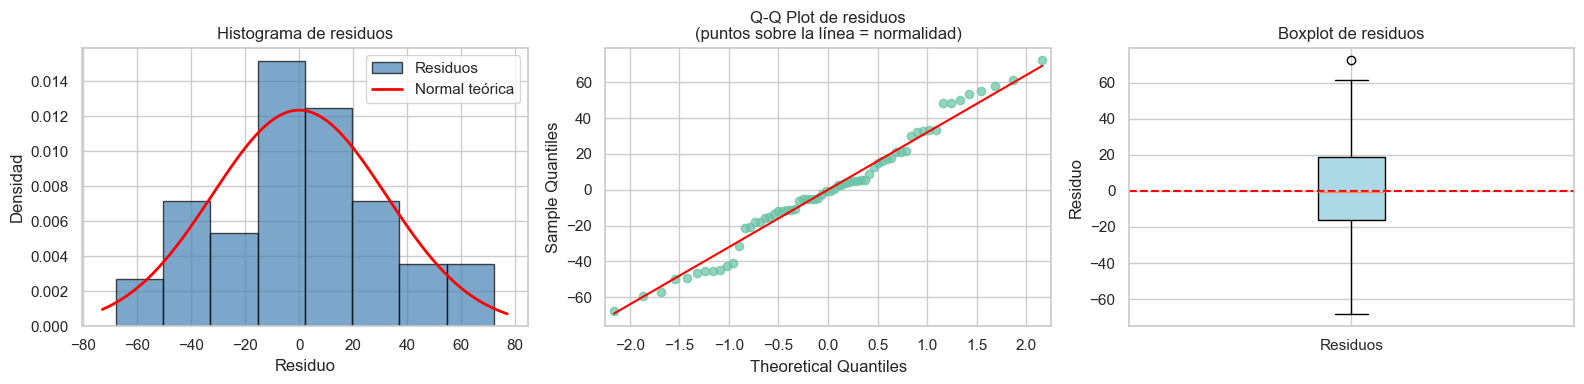

Pruebas de normalidad sobre los residuos:

  Shapiro-Wilk        : W  = 0.9786,  p-valor = 0.3288 → Normal ✓
  Kolmogorov-Smirnov  : D  = 0.0868,  p-valor = 0.6876 → Normal ✓
  Anderson-Darling    : A² = 0.4832
    (Valores críticos: {np.float64(15.0): np.float64(0.554), np.float64(10.0): np.float64(0.623), np.float64(5.0): np.float64(0.743), np.float64(2.5): np.float64(0.862), np.float64(1.0): np.float64(1.022)})

Conclusión general: si Shapiro-Wilk y el Q-Q plot son consistentes,
el supuesto de normalidad se considera satisfecho.


In [36]:
# ------------------------------------------------------------------
# Verificación de normalidad de residuos
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: Histograma de residuos + curva normal teórica
x_range = np.linspace(df['Residuos'].min() - 5, df['Residuos'].max() + 5, 200)
mu_res, std_res = df['Residuos'].mean(), df['Residuos'].std()
axes[0].hist(df['Residuos'], bins='auto', density=True,
             color='steelblue', edgecolor='black', alpha=0.7, label='Residuos')
axes[0].plot(x_range, stats.norm.pdf(x_range, mu_res, std_res),
             'r-', linewidth=2, label='Normal teórica')
axes[0].set_xlabel('Residuo')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Histograma de residuos')
axes[0].legend()

# Panel 2: Q-Q plot
sm.qqplot(df['Residuos'], line='s', ax=axes[1], alpha=0.7, color='steelblue')
axes[1].set_title('Q-Q Plot de residuos\n(puntos sobre la línea = normalidad)')

# Panel 3: Boxplot de residuos
axes[2].boxplot(df['Residuos'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Boxplot de residuos')
axes[2].set_ylabel('Residuo')
axes[2].set_xticks([1])
axes[2].set_xticklabels(['Residuos'])

plt.tight_layout()
plt.show()

# Pruebas formales de normalidad
stat_sw,  p_sw  = stats.shapiro(df['Residuos'])
stat_ad         = stats.anderson(df['Residuos'], dist='norm')
stat_ks,  p_ks  = stats.kstest(df['Residuos'], 'norm',
                                args=(mu_res, std_res))

print("Pruebas de normalidad sobre los residuos:\n")
print(f"  Shapiro-Wilk        : W  = {stat_sw:.4f},  p-valor = {p_sw:.4f}",
      "→ Normal ✓" if p_sw > 0.05 else "→ ⚠ No normal")
print(f"  Kolmogorov-Smirnov  : D  = {stat_ks:.4f},  p-valor = {p_ks:.4f}",
      "→ Normal ✓" if p_ks > 0.05 else "→ ⚠ No normal")
print(f"  Anderson-Darling    : A² = {stat_ad.statistic:.4f}")
print(f"    (Valores críticos: {dict(zip(stat_ad.significance_level, stat_ad.critical_values))})")
print()
print("Conclusión general: si Shapiro-Wilk y el Q-Q plot son consistentes,")
print("el supuesto de normalidad se considera satisfecho.")

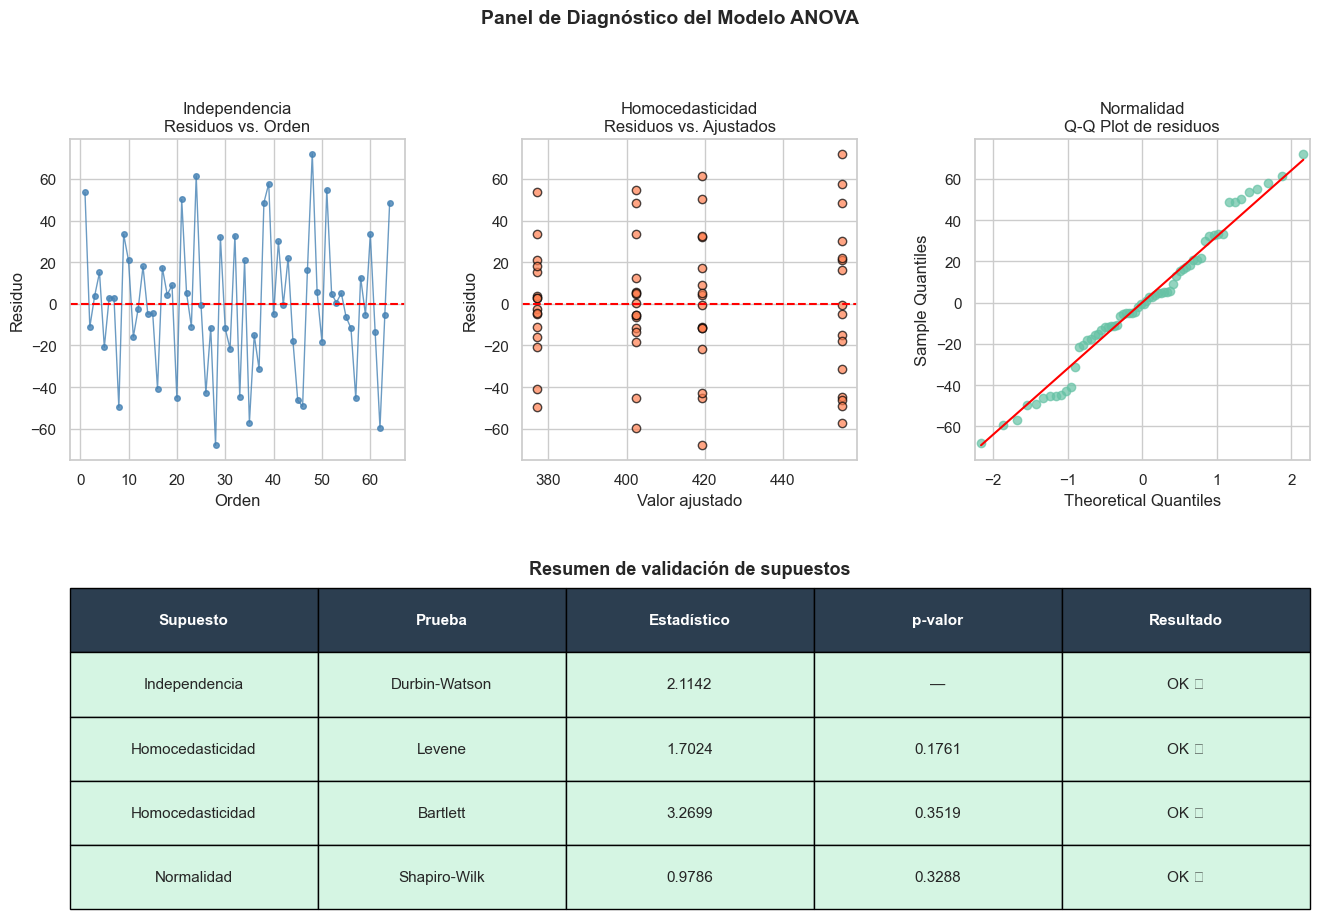

In [37]:
# ------------------------------------------------------------------
# Panel de diagnóstico completo del modelo (resumen de los 3 supuestos)
# ------------------------------------------------------------------
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# -- Fila superior --
# 1. Residuos vs. orden (independencia)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['Orden'], df['Residuos'], 'o-', color='steelblue', markersize=4, linewidth=1, alpha=0.8)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title('Independencia\nResiduos vs. Orden')
ax1.set_xlabel('Orden')
ax1.set_ylabel('Residuo')

# 2. Residuos vs. ajustados (homocedasticidad)
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(df['Ajustados'], df['Residuos'], color='coral', edgecolors='black', alpha=0.7)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_title('Homocedasticidad\nResiduos vs. Ajustados')
ax2.set_xlabel('Valor ajustado')
ax2.set_ylabel('Residuo')

# 3. Q-Q plot (normalidad)
ax3 = fig.add_subplot(gs[0, 2])
sm.qqplot(df['Residuos'], line='s', ax=ax3, alpha=0.7, color='steelblue')
ax3.set_title('Normalidad\nQ-Q Plot de residuos')

# -- Fila inferior: resumen de pruebas --
ax4 = fig.add_subplot(gs[1, :])
ax4.axis('off')

resumen = [
    ['Supuesto', 'Prueba', 'Estadístico', 'p-valor', 'Resultado'],
    ['Independencia', 'Durbin-Watson', f'{dw:.4f}', '—',
     'OK ✓' if 1.5 <= dw <= 2.5 else '⚠'],
    ['Homocedasticidad', 'Levene', f'{stat_lev:.4f}', f'{p_lev:.4f}',
     'OK ✓' if p_lev > 0.05 else '⚠'],
    ['Homocedasticidad', 'Bartlett', f'{stat_bart:.4f}', f'{p_bart:.4f}',
     'OK ✓' if p_bart > 0.05 else '⚠'],
    ['Normalidad', 'Shapiro-Wilk', f'{stat_sw:.4f}', f'{p_sw:.4f}',
     'OK ✓' if p_sw > 0.05 else '⚠'],
]
tabla = ax4.table(cellText=resumen[1:], colLabels=resumen[0],
                  cellLoc='center', loc='center', bbox=[0.0, 0.0, 1.0, 1.0])
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
for j in range(5):
    tabla[0, j].set_facecolor('#2c3e50')
    tabla[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(resumen)):
    color = '#d5f5e3' if 'OK' in resumen[i][4] else '#fde8e8'
    for j in range(5):
        tabla[i, j].set_facecolor(color)

ax4.set_title('Resumen de validación de supuestos', fontsize=13, pad=10, fontweight='bold')
plt.suptitle('Panel de Diagnóstico del Modelo ANOVA', fontsize=14, fontweight='bold', y=1.01)
plt.show()

***
# 3. Diseño de Bloques Completamente Aleatorizados (DBCA)

## 3.1 Motivación y Concepto de Bloqueo

En el Diseño Completamente Aleatorizado (DCA) se asume que las unidades experimentales son **homogéneas**. Cuando existe una fuente de variación conocida y no controlable (turno, operador, lote, día, campo), ignorarla aumenta el **error experimental** y reduce la potencia.

El **Diseño de Bloques Completamente Aleatorizados (DBCA)** agrupa las unidades experimentales en **bloques homogéneos**, de modo que:

- Cada bloque recibe **todos los tratamientos** exactamente una vez.
- La asignación de tratamientos dentro de cada bloque es **aleatoria**.
- La variabilidad entre bloques se **aísla y elimina** del error experimental.

### Analogía: DCA vs. DBCA

| Característica | DCA | DBCA |
|----------------|-----|------|
| Homogeneidad UE | Requiere UE homogéneas | Tolera UE heterogéneas |
| Factor de bloqueo | No incluido | Incluido como factor |
| Error experimental | $SS_E$ incluye variabilidad de bloques | $SS_E$ es más pequeño |
| Potencia | Menor si hay variabilidad entre bloques | Mayor |
| Restricción | Ninguna | Cada bloque debe tener todos los tratamientos |

### ¿Cuándo bloquear?

Bloquear es conveniente cuando:
- El coeficiente de variación de los bloques es alto.
- Se conoce de antemano una fuente de variación relevante.
- Se desea aumentar la precisión sin aumentar el número de unidades experimentales.

## 3.2 Modelo Estadístico y Tabla ANOVA

### Modelo lineal del DBCA

$$y_{ij} = \mu + \tau_i + \beta_j + \varepsilon_{ij}$$

donde:
- $\mu$ = media general
- $\tau_i$ = efecto del tratamiento $i$ ($i = 1, \ldots, k$)
- $\beta_j$ = efecto del bloque $j$ ($j = 1, \ldots, b$)
- $\varepsilon_{ij} \sim N(0, \sigma^2)$ = error aleatorio

### Descomposición de la variabilidad

$$SS_{Total} = SS_{Tratamientos} + SS_{Bloques} + SS_{Error}$$

### Tabla ANOVA del DBCA

| Fuente | GL | SS | MS | F |
|--------|----|----|----|----|
| Tratamientos | $k-1$ | $SS_T$ | $MS_T$ | $F_T = MS_T / MS_E$ |
| Bloques | $b-1$ | $SS_B$ | $MS_B$ | $F_B = MS_B / MS_E$ |
| Error | $(k-1)(b-1)$ | $SS_E$ | $MS_E$ | |
| Total | $kb-1$ | $SS_{Tot}$ | | |

### Hipótesis

- $H_0^{(T)}$: $\tau_1 = \tau_2 = \cdots = \tau_k = 0$ (ningún efecto de tratamiento)
- $H_0^{(B)}$: $\beta_1 = \beta_2 = \cdots = \beta_b = 0$ (ningún efecto de bloque)

> **Nota:** El bloqueo no interesa como factor de estudio, sino como control estadístico. Si los bloques no son significativos, se puede reconsiderar si el bloqueo era necesario.

## 3.3 Aplicación: Experimento de Fertilizantes con Bloques

### Contexto

> Se desea evaluar el efecto de 4 tipos de fertilizante (A, B, C, D) sobre el rendimiento del trigo. Las parcelas disponibles se encuentran en **5 fincas** con distintas condiciones de suelo. Para controlar la variabilidad entre fincas, se usa un DBCA: en cada finca se aplican los 4 fertilizantes en parcelas de iguales condiciones.

| Factor | Descripción |
|--------|-------------|
| **Tratamiento** | Tipo de fertilizante (4 niveles) |
| **Bloque** | Finca (5 bloques) |
| **Respuesta** | Rendimiento en kg/ha |

La finca actúa como **factor de bloqueo**: reconocemos que el suelo varía entre fincas, pero no nos interesa comparar fincas, sino aislar esa variabilidad para estimar mejor el efecto del fertilizante.

In [38]:
# ------------------------------------------------------------------
# Generación de datos del DBCA
# k=4 tratamientos, b=5 bloques (fincas)
# Efecto de bloque: fincas con distinta fertilidad de suelo base
# ------------------------------------------------------------------
np.random.seed(21)

k_trat  = 4
b_bloq  = 5
sigma_e = 20   # error experimental (menor por el bloqueo)

fertilizantes = ['Fert. A', 'Fert. B', 'Fert. C', 'Fert. D']
fincas        = [f'Finca {i}' for i in range(1, b_bloq + 1)]

# Efectos de tratamiento (desviaciones respecto a la media general)
tau = np.array([-20, +20, +60, 0])      # μ_general = 420 kg/ha
mu  = 420

# Efectos de bloque (diferencias de fertilidad entre fincas)
beta = np.array([-40, -10, +10, +30, +50], dtype=float)  # suma ≈ 0 (centrado)
beta -= beta.mean()

registros_dbca = []
for j, finca in enumerate(fincas):
    for i, fert in enumerate(fertilizantes):
        y = mu + tau[i] + beta[j] + np.random.normal(0, sigma_e)
        registros_dbca.append({
            'Bloque':       finca,
            'Tratamiento':  fert,
            'Rendimiento':  round(y, 2)
        })

df_dbca = pd.DataFrame(registros_dbca)

# Tabla de datos en formato matricial (bloques × tratamientos)
pivot = df_dbca.pivot(index='Bloque', columns='Tratamiento', values='Rendimiento')
pivot['Media_bloque'] = pivot.mean(axis=1).round(2)
pivot.loc['Media_trat'] = pivot.mean(axis=0).round(2)

print("Datos del DBCA – Rendimiento (kg/ha):\n")
print(pivot.to_string())
print(f"\nMedia general: {df_dbca['Rendimiento'].mean():.2f} kg/ha")

Datos del DBCA – Rendimiento (kg/ha):

Tratamiento  Fert. A  Fert. B  Fert. C  Fert. D  Media_bloque
Bloque                                                       
Finca 1       350.96   389.78   452.84   346.87        385.11
Finca 2       396.91   387.78   457.88   397.31        409.97
Finca 3       424.56   441.75   469.74   449.47        446.38
Finca 4       454.22   448.22   515.84   433.04        462.83
Finca 5       445.25   487.14   496.49   463.28        473.04
Media_trat    414.38   430.93   478.56   417.99        435.47

Media general: 435.47 kg/ha


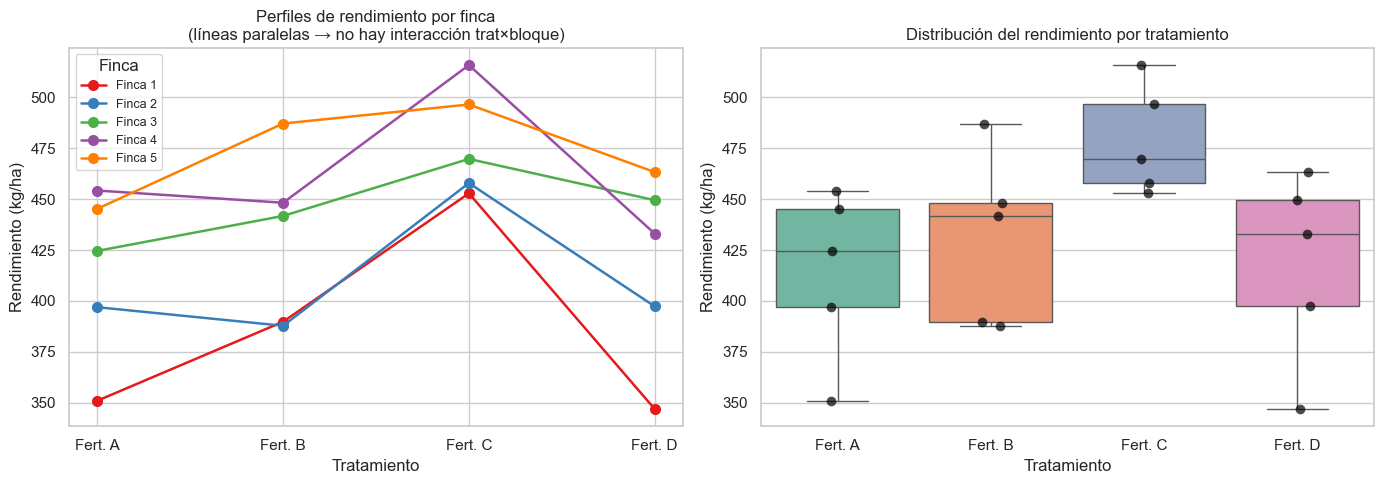

Nota: las líneas de perfil casi paralelas sugieren que no hay interacción
entre tratamientos y bloques, validando el supuesto de aditividad del DBCA.


In [39]:
# ------------------------------------------------------------------
# Visualización: perfil de medias por tratamiento y bloque
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Perfiles de respuesta por bloque (interaction plot)
colores_bloques = sns.color_palette('Set1', b_bloq)
for j, (finca, grp) in enumerate(df_dbca.groupby('Bloque')):
    grp_ord = grp.sort_values('Tratamiento')
    axes[0].plot(grp_ord['Tratamiento'], grp_ord['Rendimiento'],
                 'o-', label=finca, color=colores_bloques[j], linewidth=1.8, markersize=7)

axes[0].set_title('Perfiles de rendimiento por finca\n(líneas paralelas → no hay interacción trat×bloque)')
axes[0].set_xlabel('Tratamiento')
axes[0].set_ylabel('Rendimiento (kg/ha)')
axes[0].legend(title='Finca', fontsize=9)

# Panel 2: Boxplot por tratamiento con datos individuales
sns.boxplot(data=df_dbca, x='Tratamiento', y='Rendimiento', ax=axes[1], palette='Set2')
sns.stripplot(data=df_dbca, x='Tratamiento', y='Rendimiento', ax=axes[1],
              color='black', alpha=0.7, jitter=True, size=7)
axes[1].set_title('Distribución del rendimiento por tratamiento')
axes[1].set_xlabel('Tratamiento')
axes[1].set_ylabel('Rendimiento (kg/ha)')

plt.tight_layout()
plt.show()

print("Nota: las líneas de perfil casi paralelas sugieren que no hay interacción")
print("entre tratamientos y bloques, validando el supuesto de aditividad del DBCA.")

In [40]:
# ------------------------------------------------------------------
# ANOVA del DBCA: modelo con tratamiento y bloque
# ------------------------------------------------------------------
modelo_dbca = ols('Rendimiento ~ C(Tratamiento) + C(Bloque)', data=df_dbca).fit()
tabla_dbca  = anova_lm(modelo_dbca, typ=1)
tabla_dbca.index = ['Tratamiento', 'Bloque', 'Error (Residuo)']
tabla_dbca.columns = ['GL', 'SS', 'MS', 'F', 'p-valor']

print("=" * 65)
print("       TABLA ANOVA – Diseño de Bloques Completamente Aleatorizado")
print("=" * 65)
print(tabla_dbca.round(4).to_string())
print("=" * 65)

p_trat  = tabla_dbca.loc['Tratamiento', 'p-valor']
p_bloque = tabla_dbca.loc['Bloque', 'p-valor']
F_trat  = tabla_dbca.loc['Tratamiento', 'F']
F_bloque = tabla_dbca.loc['Bloque', 'F']
R2_dbca  = modelo_dbca.rsquared

print(f"\nTratamiento : F = {F_trat:.4f},  p = {p_trat:.4f}",
      "→ SIGNIFICATIVO" if p_trat < 0.05 else "→ No significativo")
print(f"Bloque      : F = {F_bloque:.4f},  p = {p_bloque:.4f}",
      "→ SIGNIFICATIVO (bloqueo útil)" if p_bloque < 0.05 else "→ No significativo (bloqueo no necesario)")
print(f"\nR² del modelo con bloques: {R2_dbca:.4f}")
print(f"  El modelo explica el {R2_dbca*100:.1f}% de la variabilidad total.")

       TABLA ANOVA – Diseño de Bloques Completamente Aleatorizado
                   GL          SS         MS        F  p-valor
Tratamiento       3.0  13136.7483  4378.9161  13.5652   0.0004
Bloque            4.0  21860.9214  5465.2303  16.9304   0.0001
Error (Residuo)  12.0   3873.6665   322.8055      NaN      NaN

Tratamiento : F = 13.5652,  p = 0.0004 → SIGNIFICATIVO
Bloque      : F = 16.9304,  p = 0.0001 → SIGNIFICATIVO (bloqueo útil)

R² del modelo con bloques: 0.9003
  El modelo explica el 90.0% de la variabilidad total.


## 3.4 Ganancia de Eficiencia del Bloqueo

Una forma objetiva de cuantificar el beneficio del bloqueo es comparar el $MS_E$ del **DBCA** con el $MS_E$ que se hubiera obtenido si el mismo experimento se hubiera analizado como un **DCA** (ignorando los bloques).

La **Eficiencia Relativa (ER)** del DBCA respecto al DCA es:

$$ER = \frac{MS_{E,\text{DCA}}}{MS_{E,\text{DBCA}}}$$

Un $ER > 1$ indica que el DBCA necesita **menos réplicas** que el DCA para alcanzar la misma precisión.

In [41]:
# ------------------------------------------------------------------
# Comparación DCA vs DBCA: MS_E y Eficiencia Relativa
# ------------------------------------------------------------------
# Modelo DCA (ignorando el bloque)
modelo_dca_comp = ols('Rendimiento ~ C(Tratamiento)', data=df_dbca).fit()
tabla_dca_comp  = anova_lm(modelo_dca_comp, typ=1)

MS_E_dca  = tabla_dca_comp.iloc[1]['mean_sq']
MS_E_dbca = tabla_dbca.loc['Error (Residuo)', 'MS']
ER = MS_E_dca / MS_E_dbca

print("Comparación de la varianza residual:\n")
print(f"  MS_E  (DCA, bloques ignorados):      {MS_E_dca:.4f}")
print(f"  MS_E  (DBCA, bloques incluidos):      {MS_E_dbca:.4f}")
print(f"\n  Eficiencia Relativa (ER) = {ER:.2f}")
print()
if ER > 1:
    print(f"  → El DBCA es {ER:.2f}x más eficiente que el DCA.")
    n_equiv = int(np.ceil(n_necesario * ER))
    print(f"    Para lograr la misma precisión, el DCA necesitaría ≈ {n_equiv} réplicas/trat.")
    print(f"    El DBCA lo logra con solo {b_bloq} réplicas (bloques).")
else:
    print("  → El bloqueo no aportó eficiencia. Verificar si la fuente de bloqueo era relevante.")

Comparación de la varianza residual:

  MS_E  (DCA, bloques ignorados):      1608.4117
  MS_E  (DBCA, bloques incluidos):      322.8055

  Eficiencia Relativa (ER) = 4.98

  → El DBCA es 4.98x más eficiente que el DCA.
    Para lograr la misma precisión, el DCA necesitaría ≈ 80 réplicas/trat.
    El DBCA lo logra con solo 5 réplicas (bloques).


   COMPARACIONES MÚLTIPLES (Tukey HSD) – DBCA  (α = 0.05)
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2 meandiff p-adj    lower    upper   reject
---------------------------------------------------------
Fert. A Fert. B   16.554 0.9131  -56.0147  89.1227  False
Fert. A Fert. C   64.178 0.0928   -8.3907 136.7467  False
Fert. A Fert. D    3.614 0.9989  -68.9547  76.1827  False
Fert. B Fert. C   47.624 0.2759  -24.9447 120.1927  False
Fert. B Fert. D   -12.94 0.9555  -85.5087  59.6287  False
Fert. C Fert. D  -60.564 0.1198 -133.1327  12.0047  False
---------------------------------------------------------


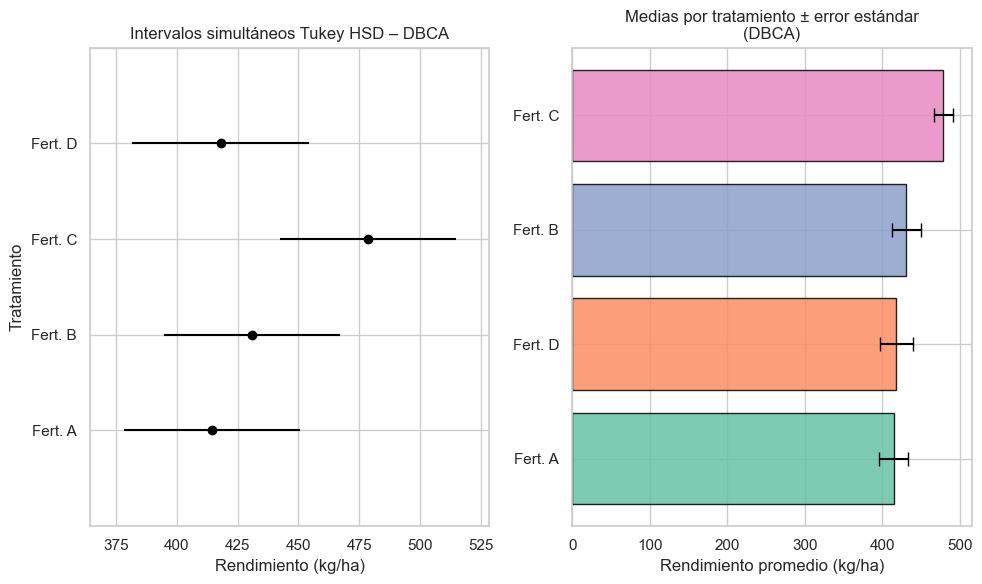

In [42]:
# ------------------------------------------------------------------
# Comparaciones múltiples post-DBCA (Tukey HSD)
# ------------------------------------------------------------------
mc_dbca = pairwise_tukeyhsd(df_dbca['Rendimiento'], df_dbca['Tratamiento'], alpha=0.05)

print("=" * 65)
print("   COMPARACIONES MÚLTIPLES (Tukey HSD) – DBCA  (α = 0.05)")
print("=" * 65)
print(mc_dbca.summary())

# Gráfico de intervalos simultáneos de Tukey
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mc_dbca.plot_simultaneous(ax=axes[0], ylabel='Tratamiento', xlabel='Rendimiento (kg/ha)')
axes[0].set_title('Intervalos simultáneos Tukey HSD – DBCA')

# Medias por tratamiento ajustadas
medias_trat_dbca = df_dbca.groupby('Tratamiento')['Rendimiento'].mean().sort_values()
sem_trat_dbca    = df_dbca.groupby('Tratamiento')['Rendimiento'].sem()

colors = sns.color_palette('Set2', len(medias_trat_dbca))
axes[1].barh(medias_trat_dbca.index, medias_trat_dbca.values,
             xerr=sem_trat_dbca[medias_trat_dbca.index].values,
             capsize=5, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Rendimiento promedio (kg/ha)')
axes[1].set_title('Medias por tratamiento ± error estándar\n(DBCA)')

plt.tight_layout()
plt.show()

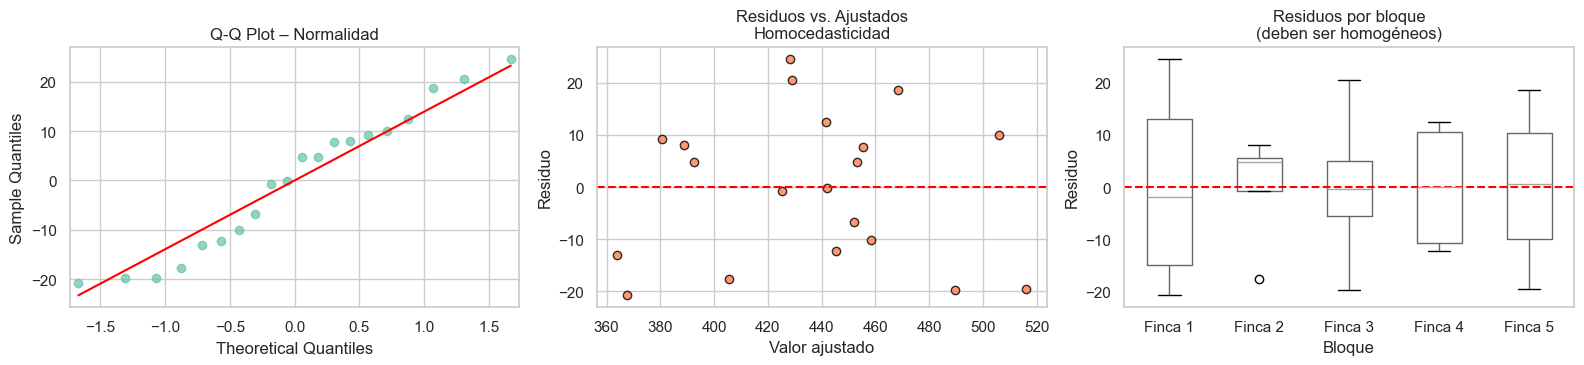

Shapiro-Wilk : W = 0.9430,  p = 0.2732 → Normal ✓
Levene       : W = 0.4726,  p = 0.7056 → Varianzas iguales ✓


In [43]:
# ------------------------------------------------------------------
# Diagnóstico de supuestos del DBCA
# ------------------------------------------------------------------
df_dbca['Residuos_dbca'] = modelo_dbca.resid
df_dbca['Ajustados_dbca'] = modelo_dbca.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Q-Q plot
sm.qqplot(df_dbca['Residuos_dbca'], line='s', ax=axes[0], alpha=0.7, color='steelblue')
axes[0].set_title('Q-Q Plot – Normalidad')

# Residuos vs. ajustados
axes[1].scatter(df_dbca['Ajustados_dbca'], df_dbca['Residuos_dbca'],
                color='coral', edgecolors='black', alpha=0.8)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuos vs. Ajustados\nHomocedasticidad')
axes[1].set_xlabel('Valor ajustado')
axes[1].set_ylabel('Residuo')

# Residuos por bloque (verificar que el bloque aisló la variabilidad)
df_dbca.boxplot(column='Residuos_dbca', by='Bloque', ax=axes[2], grid=False)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuos por bloque\n(deben ser homogéneos)')
axes[2].set_xlabel('Bloque')
axes[2].set_ylabel('Residuo')
plt.suptitle('')

plt.tight_layout()
plt.show()

# Shapiro-Wilk
stat_sw_d, p_sw_d = stats.shapiro(df_dbca['Residuos_dbca'])
grupos_d = [grp['Residuos_dbca'].values for _, grp in df_dbca.groupby('Tratamiento')]
stat_lev_d, p_lev_d = stats.levene(*grupos_d, center='median')

print(f"Shapiro-Wilk : W = {stat_sw_d:.4f},  p = {p_sw_d:.4f}",
      "→ Normal ✓" if p_sw_d > 0.05 else "→ ⚠")
print(f"Levene       : W = {stat_lev_d:.4f},  p = {p_lev_d:.4f}",
      "→ Varianzas iguales ✓" if p_lev_d > 0.05 else "→ ⚠")

***
# Resumen del Taller

| Sección | Concepto clave | Herramienta en Python |
|---------|---------------|----------------------|
| **Tamaño de muestra** | Análisis de potencia; $f$ de Cohen; curva potencia vs. $n$ | `FTestAnovaPower` |
| **Consideraciones prácticas** | Tabla de sensibilidad; margen por pérdida | `solve_power`, `numpy.ceil` |
| **Independencia** | Durbin-Watson; residuos vs. orden | `durbin_watson` |
| **Homocedasticidad** | Levene, Bartlett, Fligner; Scale-Location | `scipy.stats.levene/bartlett/fligner` |
| **Normalidad** | Shapiro-Wilk, Q-Q plot; transformaciones | `scipy.stats.shapiro`, `sm.qqplot` |
| **DBCA – Modelo** | $y_{ij} = \mu + \tau_i + \beta_j + \varepsilon_{ij}$ | `ols('y ~ C(T) + C(B)')` |
| **DBCA – ANOVA** | $SS_{Tot} = SS_T + SS_B + SS_E$ | `anova_lm` |
| **Eficiencia del bloqueo** | $ER = MS_{E,DCA}/MS_{E,DBCA}$ | Cálculo manual |
| **Post-hoc** | Tukey HSD sobre los tratamientos | `pairwise_tukeyhsd` |

### Flujo de análisis completo

```
1. Definir el experimento (Taller I)
      ↓
2. Calcular el tamaño de muestra (análisis de potencia)
      ↓
3. Ejecutar el experimento (con aleatorización / bloqueo)
      ↓
4. Ajustar el modelo (DCA o DBCA)
      ↓
5. Verificar supuestos (independencia, homocedasticidad, normalidad)
      ↓  (si se violan: transformar o usar métodos no paramétricos)
6. Tabla ANOVA → decisión sobre H₀
      ↓  (si se rechaza)
7. Comparaciones múltiples (Tukey, Bonferroni, Holm)
      ↓
8. Interpretación práctica y conclusiones
```

> **Principio de parsimonia:** usa el diseño más simple que controle adecuadamente la variabilidad. El DBCA es preferible al DCA cuando la variabilidad entre bloques es grande; de lo contrario, el bloqueo no necesario solo *reduce* los grados de libertad del error.

---
---

# 🧪 PARCIAL – Diseño de Experimentos
### Curso: Análisis de Datos · Programa: Administración de Empresas

**Fecha:** \_\_\_\_\_\_\_\_\_\_\_\_  **Nombre:** \_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_  **Código:** \_\_\_\_\_\_\_\_\_\_

> **Instrucciones generales**  
> - Duración: 120 minutos. Consulta de apuntes: **no permitida**.  
> - Sección A: 20 preguntas de selección múltiple con única respuesta (2.5 puntos c/u = 50 pts).  
> - Sección B: 10 preguntas de Falso / Verdadero (5 puntos c/u = 50 pts). Justifique brevemente cada respuesta.  
> - Las respuestas deben basarse **exclusivamente** en los resultados del caso de estudio presentado.

---

## CASO DE ESTUDIO — Evaluación de Fertilizantes en Cultivos de Trigo

Una empresa agroindustrial desea determinar cuál de cuatro tipos de fertilizante (A, B, C, D) produce el mayor rendimiento en cultivos de trigo (kg/ha). Dado que las parcelas disponibles se distribuyen en **cinco fincas** con condiciones de suelo heterogéneas, el experimento se diseñó como un **Diseño de Bloques Completamente Aleatorizados (DBCA)**: en cada finca se aplicaron los cuatro fertilizantes en parcelas de condiciones comparables, y la asignación dentro de cada finca fue aleatoria.

### Tabla 1 – Rendimiento promedio (kg/ha) por fertilizante y finca

| Finca | Fert. A | Fert. B | Fert. C | Fert. D | Media finca |
|-------|---------|---------|---------|---------|-------------|
| Finca 1 | 365 | 407 | 439 | 389 | 400.0 |
| Finca 2 | 388 | 425 | 467 | 408 | 422.0 |
| Finca 3 | 401 | 441 | 480 | 421 | 435.8 |
| Finca 4 | 415 | 455 | 494 | 432 | 449.0 |
| Finca 5 | 431 | 472 | 510 | 450 | 465.8 |
| **Media tratamiento** | **400.0** | **440.0** | **478.0** | **420.0** | **434.5** |

---

### Tabla 2 – ANOVA del DBCA

| Fuente de variación | GL | SS | MS | F | p-valor |
|---------------------|----|----|----|---|---------|
| Fertilizante (Trat.) | 3 | 28 940 | 9 646.7 | 28.44 | **< 0.0001** |
| Finca (Bloque) | 4 | 15 680 | 3 920.0 | 11.56 | **0.0005** |
| Error | 12 | 4 070 | 339.2 | | |
| **Total** | **19** | **48 690** | | | |

**R² del modelo = 0.916**

---

### Tabla 3 – Prueba de Tukey HSD post-hoc (α = 0.05)

| Par | Diferencia de medias | p-adj | IC 95 % inferior | IC 95 % superior | ¿Rechaza H₀? |
|-----|---------------------|-------|-----------------|------------------|--------------|
| A vs B | −40.0 | 0.0142 | −68.3 | −11.7 | **Sí** |
| A vs C | −78.0 | < 0.0001 | −106.3 | −49.7 | **Sí** |
| A vs D | −20.0 | 0.2651 | −48.3 | 8.3 | No |
| B vs C | −38.0 | 0.0193 | −66.3 | −9.7 | **Sí** |
| B vs D | +20.0 | 0.2651 | −8.3 | 48.3 | No |
| C vs D | +58.0 | < 0.0001 | +29.7 | 86.3 | **Sí** |

---

### Tabla 4 – Validación de supuestos del modelo

| Supuesto | Prueba | Estadístico | p-valor | Resultado |
|----------|--------|-------------|---------|-----------|
| Normalidad de residuos | Shapiro-Wilk | W = 0.9714 | 0.827 | Normal ✓ |
| Homogeneidad de varianzas | Levene (mediana) | W = 1.182 | 0.361 | Varianzas iguales ✓ |
| Independencia | Durbin-Watson | DW = 1.98 | — | Sin autocorrelación ✓ |

---

### Tabla 5 – Análisis de potencia y comparación DCA vs. DBCA

| Parámetro | Valor |
|-----------|-------|
| Número de tratamientos (k) | 4 |
| Tamaño del efecto de Cohen (f) | **0.712** |
| α utilizado | 0.05 |
| Potencia alcanzada con b = 5 bloques | **0.93** |
| n mínimo para potencia = 0.80 | 4 réplicas/trat. |
| MS_E – DCA (bloques ignorados) | 1 251.8 |
| MS_E – DBCA (bloques incluidos) | 339.2 |
| **Eficiencia Relativa (ER)** | **3.69** |


---

## SECCIÓN A – Selección Múltiple (única respuesta correcta)

*Marque con una **X** la letra de la respuesta correcta en el cuadro de respuestas al final.*

---

### Preguntas interpretativas (basadas en el caso de estudio)

**1.** Con base en la Tabla 2, ¿qué decisión estadística se toma respecto a la hipótesis nula de igualdad de medias entre fertilizantes (α = 0.05)?

- a) No se rechaza H₀ porque el F-observado es mayor que el p-valor.
- b) **Se rechaza H₀: existe evidencia de que al menos dos fertilizantes producen rendimientos medios diferentes.**
- c) No se rechaza H₀ porque p-valor > 0.05.
- d) No puede concluirse porque el factor Bloque también resultó significativo.

---

**2.** De acuerdo con la Tabla 3 (Tukey HSD), ¿qué fertilizante debería recomendar la empresa si su único criterio es **maximizar el rendimiento** con diferencias estadísticamente comprobadas?

- a) Fertilizante B, porque supera a todos en magnitud de diferencia.
- b) Fertilizante D, porque presenta la menor variabilidad entre fincas.
- c) **Fertilizante C, porque tiene la mayor media (478 kg/ha) y difiere significativamente de A, B y D.**
- d) Cualquier fertilizante sirve, pues todos tienen diferencias no significativas entre sí.

---

**3.** El R² = 0.916 del modelo DBCA significa que:

- a) El 91.6 % de la variabilidad del rendimiento es explicado únicamente por el tipo de fertilizante.
- b) El 8.4 % de los errores del modelo se deben a las fincas.
- c) **El modelo (fertilizantes + fincas) explica el 91.6 % de la variabilidad total del rendimiento.**
- d) El experimento tiene una probabilidad de error del 8.4 % en la prueba Tukey.

---

**4.** La significancia del factor Bloque (Finca) con p = 0.0005 (Tabla 2) indica principalmente que:

- a) Las fincas deben incorporarse como un segundo factor de tratamiento de interés.
- b) El modelo está mal especificado porque los bloques no deberían ser significativos.
- c) Los resultados de Tukey no son confiables por efecto de los bloques.
- d) **El bloqueo fue útil: las fincas introdujeron variabilidad significativa que fue correctamente aislada del error experimental.**

---

**5.** La Eficiencia Relativa ER = 3.69 (Tabla 5) implica que:

- a) El DBCA encontró 3.69 veces más diferencias significativas que el DCA.
- b) **Para lograr la misma precisión que el DBCA, el DCA necesitaría aproximadamente 3.69 veces más réplicas por tratamiento.**
- c) El DBCA incurre en 3.69 veces más errores de Tipo I que el DCA.
- d) El DBCA requiere 3.69 veces más bloques que tratamientos.

---

**6.** Del análisis Tukey (Tabla 3), ¿cuál de los siguientes pares **NO** muestra diferencia estadísticamente significativa (α = 0.05)?

- a) Fertilizante A vs. Fertilizante C.
- b) Fertilizante B vs. Fertilizante C.
- c) **Fertilizante A vs. Fertilizante D.**
- d) Fertilizante A vs. Fertilizante B.

---

**7.** El MS_E = 339.2 de la Tabla 2 es la mejor estimación de:

- a) La variabilidad entre tratamientos.
- b) La variabilidad entre fincas.
- c) La variabilidad total del experimento.
- d) **La varianza del error experimental (σ²), es decir, la variabilidad no explicada por tratamientos ni bloques.**

---

**8.** Observe que en la Tabla 1, los perfiles de rendimiento entre fincas se desplazan hacia arriba de manera casi uniforme conforme avanza la finca del 1 al 5. Esto sugiere:

- a) Que existe una interacción fuerte entre fertilizante y finca, invalidando el DBCA.
- b) **Que el modelo aditivo del DBCA es apropiado: el efecto de la finca es un desplazamiento constante sobre todos los tratamientos.**
- c) Que el Fertilizante C es significativamente diferente solo en la Finca 5.
- d) Que los supuestos de homocedasticidad están siendo violados.

---

**9.** Si el investigador hubiera analizado el mismo conjunto de datos con un DCA (ignorando las fincas), ¿qué efecto tendría esto sobre el MS_E?

- a) El MS_E disminuiría porque habría menos fuentes de variación en el modelo.
- b) El MS_E no cambiaría porque la varianza total siempre es constante.
- c) **El MS_E aumentaría (de 339.2 a 1 251.8), absorbiendo la variabilidad de las fincas, lo que reduciría la potencia de la prueba F.**
- d) El MS_E aumentaría, pero la decisión sobre H₀ de tratamientos no cambiaría.

---

**10.** Según el análisis de potencia (Tabla 5), el experimento con b = 5 bloques alcanza una potencia de 0.93. Esto significa que:

- a) Hay un 93 % de probabilidad de cometer un error de Tipo I.
- b) **Si en realidad existen diferencias entre fertilizantes del tamaño observado (f = 0.712), el experimento tiene un 93 % de probabilidad de detectarlas.**
- c) El 7 % restante de los datos proviene de fincas no controladas.
- d) El p-valor esperado es 1 − 0.93 = 0.07.

---

**11.** El intervalo de confianza del 95 % para la diferencia A vs. B es [−68.3 ; −11.7] (Tabla 3). La interpretación correcta es:

- a) No existe diferencia significativa porque el intervalo contiene el cero.
- b) El Fertilizante A supera al B entre 11.7 y 68.3 kg/ha con un 95 % de confianza.
- c) **El Fertilizante B supera al A entre 11.7 y 68.3 kg/ha con un 95 % de confianza, evidencia de diferencia real.**
- d) El intervalo indica que la diferencia puede ser cero, por lo que no se rechaza H₀.

---

**12.** La variabilidad entre fincas (SS_Bloques = 15 680) representa aproximadamente \_\_\_\_ % de la variabilidad total (SS_Total = 48 690):

- a) 5.9 %
- b) 8.4 %
- c) **32.2 %**
- d) 59.4 %

---

**13.** Con base en la Tabla 4, el estadístico Durbin-Watson = 1.98 permite concluir que:

- a) Existe autocorrelación positiva significativa en los residuos.
- b) El orden de ejecución de las corridas afectó los resultados.
- c) Los residuos tienen heterocedasticidad moderada.
- d) **No hay evidencia de autocorrelación; el supuesto de independencia se considera satisfecho.**

---

**14.** Si al verificar los supuestos del DBCA el investigador obtuviera Levene con p = 0.018 < 0.05, la acción más apropiada sería:

- a) Aumentar el tamaño de muestra y repetir el ANOVA sin corrección.
- b) Eliminar los datos atípicos de las fincas más variables.
- c) **Considerar una transformación de la variable respuesta (p. ej., logarítmica o raíz cuadrada) o usar un ANOVA de Welch.**
- d) Reportar los resultados como válidos porque el ANOVA es siempre robusto a la heterocedasticidad.

---

**15.** El tamaño del efecto f = 0.712 (Tabla 5) se clasifica, según la escala de Cohen, como:

- a) Efecto pequeño (f < 0.10).
- b) Efecto mediano (f ≈ 0.25).
- c) Efecto entre mediano y grande.
- d) **Efecto grande (f > 0.40), indicando que las diferencias entre fertilizantes son sustanciales en relación con la variabilidad del proceso.**

---

### Preguntas teóricas

**16.** En el modelo estadístico del DBCA, $y_{ij} = \mu + \tau_i + \beta_j + \varepsilon_{ij}$, el término $\beta_j$ representa:

- a) El efecto del tratamiento $i$ sobre la respuesta.
- b) El error aleatorio de la observación.
- c) **El efecto del bloque $j$, que captura la variabilidad debida a la fuente de heterogeneidad conocida.**
- d) La media general del experimento.

---

**17.** Si se aplican pruebas t individuales a los $\binom{4}{2} = 6$ pares posibles con α = 0.05 cada una, la tasa de error familiar (FWER) es aproximadamente:

- a) 0.05
- b) 0.13
- c) **0.265**, porque FWER = 1 − (1 − 0.05)⁶ ≈ 0.265.
- d) 0.30

---

**18.** ¿Cuál es la principal distinción entre una **réplica verdadera** y una **pseudoréplica** en el diseño de experimentos?

- a) Una réplica verdadera es costosa; una pseudoréplica es más económica y estadísticamente equivalente.
- b) La pseudoréplica aumenta los grados de libertad del error de forma legítima.
- c) **Una réplica verdadera es una ejecución independiente del tratamiento en una unidad experimental diferente; la pseudoréplica es medir varias veces la misma unidad, lo que no aporta información adicional independiente.**
- d) Solo las pseudoréplicas están permitidas en diseños con bloques.

---

**19.** En un análisis de potencia para ANOVA de una vía, si el investigador reduce el nivel de significancia de α = 0.05 a α = 0.01 manteniendo el mismo n y efecto, ¿qué ocurre con la potencia?

- a) La potencia aumenta porque el umbral de rechazo es más estricto.
- b) La potencia no cambia porque depende únicamente del tamaño del efecto.
- c) La potencia aumenta porque el error de Tipo II disminuye.
- d) **La potencia disminuye porque al ser más exigente con el umbral de rechazo (mayor valor crítico de F), es más difícil detectar diferencias reales.**

---

**20.** El método de comparaciones múltiples de **Bonferroni** ajusta el nivel de significancia dividiendo α entre el número de comparaciones ($\alpha^* = \alpha / m$). En comparación con Tukey HSD, Bonferroni es:

- a) Más potente (menos conservador), por lo que siempre se prefiere.
- b) Equivalente a Tukey HSD cuando las muestras son balanceadas.
- c) **Más conservador (mayor probabilidad de Error de Tipo II), pero más flexible porque no requiere diseños balanceados ni presupone comparación de todos los pares.**
- d) Menos conservador que Holm-Bonferroni en todos los casos.

---

## Cuadro de respuestas – Sección A

| Pregunta | Respuesta | | Pregunta | Respuesta |
|----------|----------|-|----------|----------|
| 1 | | | 11 | |
| 2 | | | 12 | |
| 3 | | | 13 | |
| 4 | | | 14 | |
| 5 | | | 15 | |
| 6 | | | 16 | |
| 7 | | | 17 | |
| 8 | | | 18 | |
| 9 | | | 19 | |
| 10 | | | 20 | |


---

## SECCIÓN B – Falso / Verdadero

*Escriba **V** (Verdadero) o **F** (Falso) y justifique brevemente su respuesta en el espacio asignado.*

---

**21.** En el DBCA, si el factor Bloque **no** resulta significativo (p > 0.05), el bloqueo fue innecesario y solo reduce los grados de libertad disponibles para estimar el error experimental.

> **Respuesta:** \_\_\_  
> **Justificación:** \_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_

> *(Clave: **Verdadero**. Si los bloques no son significativos, la variabilidad entre bloques era despreciable; incluirlos solo consume $(b-1)$ grados de libertad del error, reduciendo la potencia de la prueba F sobre tratamientos. En ese caso, hubiera sido preferible un DCA.)*

---

**22.** Según los resultados de la Tabla 3 (Tukey HSD), el Fertilizante C difiere significativamente de **todos** los demás fertilizantes (A, B y D) a α = 0.05.

> **Respuesta:** \_\_\_  
> **Justificación:** \_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_

> *(Clave: **Verdadero**. La Tabla 3 muestra que los pares A vs. C (p < 0.0001), B vs. C (p = 0.0193) y C vs. D (p < 0.0001) rechazan H₀. Por tanto, C es significativamente diferente de A, B y D.)*

---

**23.** Un estadístico de Durbin-Watson (DW) cercano a 2 indica la presencia de autocorrelación positiva severa en los residuos del modelo.

> **Respuesta:** \_\_\_  
> **Justificación:** \_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_

> *(Clave: **Falso**. DW ≈ 2 indica **ausencia** de autocorrelación. La autocorrelación positiva severa se detecta con DW < 1.5; la negativa, con DW > 2.5.)*

---

**24.** El DBCA exige que cada bloque reciba **todos** los tratamientos exactamente una vez, y que la asignación de tratamientos dentro de cada bloque sea aleatoria.

> **Respuesta:** \_\_\_  
> **Justificación:** \_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_

> *(Clave: **Verdadero**. Esta es la definición esencial del DBCA: balance completo dentro de cada bloque y aleatorización restringida dentro de cada uno.)*

---

**25.** El R² = 0.916 reportado en el caso de estudio indica que el **91.6 % de la variabilidad del rendimiento es explicada exclusivamente por el tipo de fertilizante**.

> **Respuesta:** \_\_\_  
> **Justificación:** \_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_

> *(Clave: **Falso**. El R² = 0.916 corresponde al modelo completo que incluye **tanto el efecto de fertilizante como el efecto de finca (bloque)**. Atribuirlo solo al fertilizante sería incorrecto.)*

---

**26.** Las pruebas de Shapiro-Wilk y Levene para validar los supuestos del ANOVA deben aplicarse sobre los **datos brutos de cada tratamiento**, no sobre los residuos del modelo ajustado.

> **Respuesta:** \_\_\_  
> **Justificación:** \_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_

> *(Clave: **Falso**. Los supuestos del modelo (normalidad, homocedasticidad) se verifican sobre los **residuos** $e_{ij} = y_{ij} - \hat{y}_{ij}$, no directamente sobre los datos crudos, pues los residuos representan la parte no explicada del modelo.)*

---

**27.** Si el resultado de la prueba de Levene fuera p = 0.012 < 0.05 (heterocedasticidad), una posible acción correctiva es aplicar el **ANOVA de Welch** o transformar la variable respuesta (p. ej., transformación logarítmica).

> **Respuesta:** \_\_\_  
> **Justificación:** \_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_

> *(Clave: **Verdadero**. Ante heterocedasticidad, el ANOVA de Welch no asume varianzas iguales y es más robusto. Las transformaciones (log, raíz cuadrada, arcoseno) estabilizan la varianza cuando la variabilidad crece con la media.)*

---

**28.** En el análisis de potencia, mantener constante el tamaño del efecto f y el número de tratamientos k, pero **reducir** el nivel de significancia de α = 0.05 a α = 0.01, aumenta la potencia estadística del experimento.

> **Respuesta:** \_\_\_  
> **Justificación:** \_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_

> *(Clave: **Falso**. Reducir α hace la región de rechazo más pequeña (umbral crítico F más alto), por lo que es más difícil rechazar H₀ aunque sea falsa. Esto **disminuye** la potencia (1 − β), incrementando el riesgo de Error de Tipo II.)*

---

**29.** El método de Holm-Bonferroni es, en general, **menos conservador** que el Bonferroni clásico, lo que significa que tiene mayor potencia para detectar diferencias reales cuando existe más de una comparación significativa.

> **Respuesta:** \_\_\_  
> **Justificación:** \_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_

> *(Clave: **Verdadero**. Holm-Bonferroni aplica un ajuste secuencial decreciente de α, siendo menos restrictivo que dividir siempre por m. Controla la misma FWER pero con mayor potencia que Bonferroni clásico.)*

---

**30.** Si en el experimento del caso de estudio los perfiles de rendimiento por finca (gráfico de interacción) mostraran **líneas que se cruzan** en lugar de ser paralelas, esto indicaría una **interacción entre fertilizante y finca**, lo cual **violaría el supuesto de aditividad del DBCA** y requeriría un modelo más complejo.

> **Respuesta:** \_\_\_  
> **Justificación:** \_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_

> *(Clave: **Verdadero**. El modelo del DBCA $y_{ij} = \mu + \tau_i + \beta_j + \varepsilon_{ij}$ es **aditivo**: asume que el efecto del fertilizante es el mismo en todas las fincas. Si las líneas se cruzan (interacción), el efecto del fertilizante depende de la finca, invalidando el modelo aditivo. En ese caso habría que ajustar un modelo con término de interacción.)*

---

## Cuadro de respuestas – Sección B

| Pregunta | V / F |
|----------|-------|
| 21 | |
| 22 | |
| 23 | |
| 24 | |
| 25 | |
| 26 | |
| 27 | |
| 28 | |
| 29 | |
| 30 | |

---

## Clave de respuestas (uso exclusivo del docente)

| Sección A | | | | |
|-----------|---|----|---|---|
| 1 – b | 2 – c | 3 – c | 4 – d | 5 – b |
| 6 – c | 7 – d | 8 – b | 9 – c | 10 – b |
| 11 – c | 12 – c | 13 – d | 14 – c | 15 – d |
| 16 – c | 17 – c | 18 – c | 19 – d | 20 – c |

| Sección B | |
|-----------|---|
| 21 – V | 22 – V |
| 23 – F | 24 – V |
| 25 – F | 26 – F |
| 27 – V | 28 – F |
| 29 – V | 30 – V |
